This file is for exploring the donations data.

In [1]:
import pandas as pd

# Read in data
df = pd.read_csv("donation_stats.csv", sep=",")

In [2]:
df.mean(numeric_only=True).round(2)
# Interesting things:
# The percent of very large donations seems to be declining in recent years, although the average donation has gone up.
# The amount of donations missing a first name is about 600,000 more than the number with a non1a status.
# By 1a status or missing first name, corporations give larger donations than individuals (smaller percentage of #  of donations than $ amount).
#  This is  not true for LLCs or other names, which makes me suspicious of this measure.

Total_all            3179425.76
Total_L3              847561.73
pct_c_above_all            0.07
pct_c_above_L3             0.06
pct_$_above_all            0.50
pct_$_above_L3             0.37
avg_donation_all        2382.27
avg_donation_L3         2610.37
amt_non1a_all        2259202.44
amt_non1a_L3          575225.45
pct_c_non1a_all            0.47
pct_c_non1a_L3             0.47
pct_$_non1a_all            0.69
pct_$_non1a_L3             0.64
amt_nofirst_all      2822498.01
amt_nofirst_L3        771927.87
pct_c_nofirst_all          0.72
pct_c_nofirst_L3           0.75
pct_$_nofirst_all          0.86
pct_$_nofirst_L3           0.85
amt_entity_all       1405261.74
amt_entity_L3         414309.59
pct_c_entity_all           0.37
pct_c_entity_L3            0.42
pct_$_entity_all           0.36
pct_$_entity_L3            0.43
amt_allcond_all      1109546.12
amt_allcond_L3        318544.09
pct_c_allcond_all          0.24
pct_c_allcond_L3           0.27
pct_$_allcond_all          0.27
pct_$_al

<Axes: >

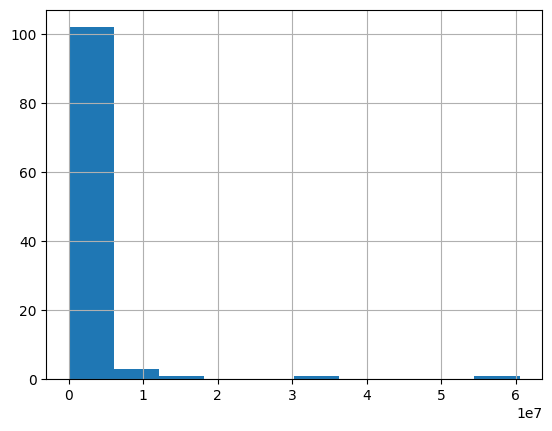

In [ ]:
# Histograms
df["Total_all"].hist()
# Most people have 1-2 million in total donations, but there are a few outliers.
# Same with percent of large donations -- very left skewed.
# And average donations (wonder if these are people who got like 3 large donations?).
# % of # of non1a donations very normally distributed but % of $ super right skewed.
# ^ both of these metrics for no first name are right skewed and both are pretty normal for entities.

<Axes: xlabel='yrs_since_first', ylabel='pct_c_nofirst_all'>

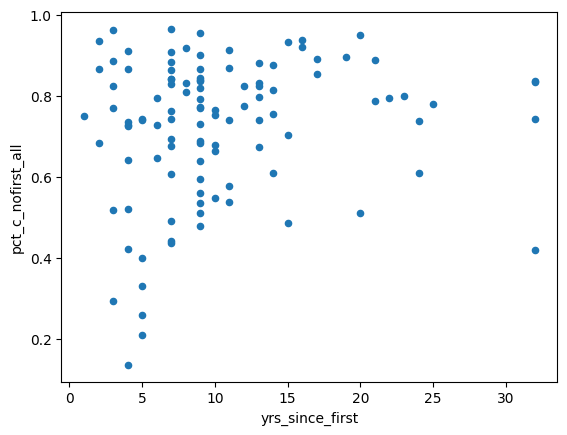

In [ ]:
# Time series (looking at candidates by 1st donation)
df.plot.scatter(x="yrs_since_first", y="pct_c_nofirst_all")
# A few weird outliers that are about 30 years ago, one super high outlier.

In [40]:
# Specific stats
# Of people with total donations in the top 10% last three, years, what percent are from corporations?
df[df["Total_L3"] >= df["Total_L3"].quantile(0.9)].mean(numeric_only=True).round(2)

Total_all            10544190.72
Total_L3              3961454.81
pct_c_above_all             0.09
pct_c_above_L3              0.10
pct_$_above_all             0.56
pct_$_above_L3              0.59
avg_donation_all         3443.67
avg_donation_L3          4122.96
amt_non1a_all         7578055.37
amt_non1a_L3          2787376.92
pct_c_non1a_all             0.49
pct_c_non1a_L3              0.47
pct_$_non1a_all             0.70
pct_$_non1a_L3              0.70
amt_nofirst_all       9907459.29
amt_nofirst_L3        3756888.68
pct_c_nofirst_all           0.76
pct_c_nofirst_L3            0.79
pct_$_nofirst_all           0.90
pct_$_nofirst_L3            0.92
amt_entity_all        5984664.58
amt_entity_L3         2265611.03
pct_c_entity_all            0.38
pct_c_entity_L3             0.43
pct_$_entity_all            0.43
pct_$_entity_L3             0.45
amt_allcond_all       4887084.68
amt_allcond_L3        1819221.69
pct_c_allcond_all           0.25
pct_c_allcond_L3            0.26
pct_$_allc

<Axes: xlabel='pct_c_non1a_all', ylabel='pct_c_above_all'>

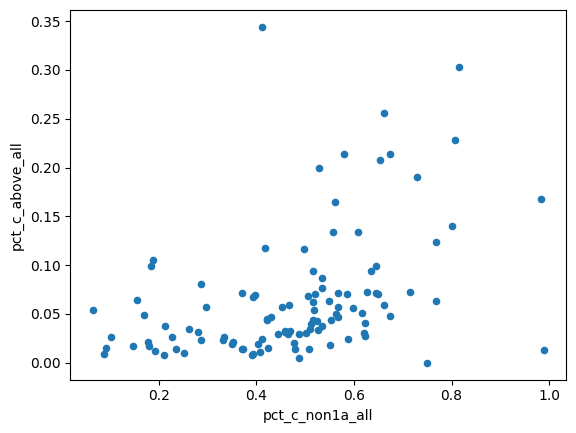

In [ ]:
# Scatter plot
df.plot.scatter(y="pct_c_above_all", x="pct_c_non1a_all")
# % of donations from corporations doesn't seem to be correlated with total or average donations.
# Higher percent of large donations corelated with percent from corporations.